<a href="https://colab.research.google.com/github/farayjtd/MLOps-Gold/blob/main/Laporan_Pipeline_MLOps_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Laporan Pipeline MLOps
## Prediksi Harga Emas XAU/USD 1 Menit ke Depan


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch
from IPython.display import Image, display
import json
import os

from google.colab import drive
drive.mount('/content/drive')

BASE_PATH = '/content/drive/MyDrive/PROYEK DATA MINING/MLOps/'
DATA_PATH = BASE_PATH + 'data/'
VISUAL_PATH = BASE_PATH + 'visuals/'
MODEL_PATH = BASE_PATH + 'models/'

print("✅ Setup selesai!")
print(f"📁 Visual path: {VISUAL_PATH}")
print(f"📁 Model path : {MODEL_PATH}")

Mounted at /content/drive
✅ Setup selesai!
📁 Visual path: /content/drive/MyDrive/PROYEK DATA MINING/MLOps/visuals/
📁 Model path : /content/drive/MyDrive/PROYEK DATA MINING/MLOps/models/


## 1. Pendahuluan

### Latar Belakang
Harga emas (XAU/USD) merupakan salah satu aset finansial paling volatile dan banyak diperdagangkan di pasar global. Prediksi harga jangka pendek (1 menit ke depan) memiliki nilai strategis tinggi untuk pengambilan keputusan trading secara real-time.

### Tujuan
1. Merancang pipeline MLOps end-to-end untuk prediksi harga emas
2. Membandingkan model XGBoost (traditional ML) vs N-HiTS (deep learning)
3. Menentukan model terbaik berdasarkan metrik evaluasi
4. Merancang skenario deployment model ke production

### Rumusan Masalah
Bagaimana merancang pipeline MLOps yang efektif untuk memprediksi harga XAU/USD 1 menit ke depan dengan akurasi tinggi menggunakan pendekatan Continuous Integration, Continuous Training, dan Continuous Deployment?

## 2. Deskripsi Kasus (Aspek 1 — Pilih Kasus Model)

### Problem Statement
- **Task**: Time Series Regression
- **Target**: Harga Close XAU/USD t+1 menit
- **Horizon**: 1 menit ke depan
- **Sumber Data**: Kaggle — novandraanugrah (XAU/USD Historical Data 2004–2024)
- **Periode**: 2004-06-11 s/d 2026-01-30
- **Total Data**: 11,381,288 baris (setelah preprocessing)
- **Jumlah Fitur**: 24 fitur
- **Model**: XGBoost & N-HiTS

### Mengapa Prediksi Harga Emas?
Emas adalah aset safe-haven yang dipengaruhi banyak faktor (geopolitik, inflasi, USD). Prediksi 1 menit ke depan sangat berguna untuk:
- Algoritmic trading otomatis
- Risk management posisi trading
- Sinyal beli/jual real-time

## 3. Exploratory Data Analysis (EDA)

### Ringkasan Dataset Raw
- **Jumlah baris raw**: 6,789,606
- **Periode**: 2004-06-11 s/d 2026-01-30
- **Harga terendah**: $381.10
- **Harga tertinggi**: $5,593.63
- **Kolom**: Open, High, Low, Close, Volume

### Temuan Anomali

| Cek | Hasil | Penanganan |
|---|---|---|
| Missing Values | 0 | ✅ Tidak perlu |
| Duplikat Timestamp | 0 | ✅ Tidak perlu |
| Harga Close ≤ 0 | 0 | ✅ Tidak perlu |
| Gap Timestamp | 214,113 kejadian | ✅ Forward fill |
| Outlier (3x IQR) | 101,401 baris | ✅ Bukan anomali* |
| High < Low | 0 | ✅ Tidak perlu |

*Outlier merupakan kenaikan harga emas wajar di periode 2024-2025 (bukan error data)

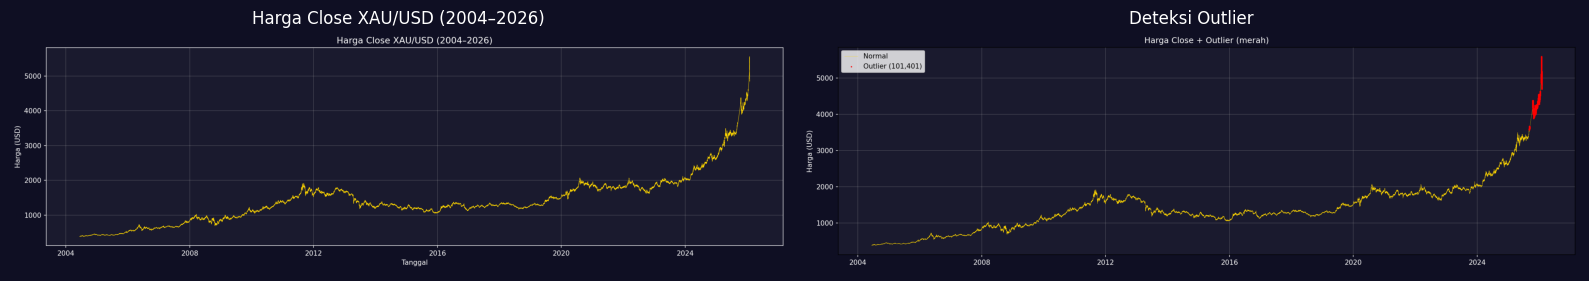

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

img1 = plt.imread(VISUAL_PATH + 'eda_harga.png')
axes[0].imshow(img1)
axes[0].axis('off')
axes[0].set_title('Harga Close XAU/USD (2004–2026)', color='white')

img2 = plt.imread(VISUAL_PATH + 'eda_outlier.png')
axes[1].imshow(img2)
axes[1].axis('off')
axes[1].set_title('Deteksi Outlier', color='white')

fig.patch.set_facecolor('#0f0f23')
plt.tight_layout()
plt.show()

## 4. Preprocessing & Feature Engineering (Aspek 1)

### Alur Preprocessing

Raw Data (6,789,606 baris)

↓

Hapus Duplikat Timestamp

↓

Fill Gap (asfreq 1min + forward fill) → +4,591,716 baris filled (40.3%)

↓

Wavelet Denoising (db4, level 3) → Hilangkan noise dari harga Close

↓

Feature Engineering (24 fitur)

↓

Adaptive Normalization (rolling window 1000 menit)

↓

Data Siap Training (11,381,288 baris, 24 fitur)

### Penjelasan Teknik Utama

**1. Forward Fill (Gap Handling)**
Pasar forex tutup weekend & holiday. Gap diisi dengan harga terakhir yang diketahui. Kolom `Is Filled` ditambahkan sebagai flag (1=filled, 0=asli) agar model tahu mana data real vs filled.

**2. Wavelet Denoising**
Menggunakan Daubechies wavelet (db4, level 3) dengan soft thresholding untuk menghilangkan noise frekuensi tinggi dari harga, menghasilkan kolom `Close Denoised`.

**3. Regime Detection (HMM)**
Hidden Markov Model dengan 3 state untuk mendeteksi kondisi pasar otomatis:
- Regime 0: Sideways
- Regime 1: Bullish
- Regime 2: Bearish

**4. Adaptive Normalization**
Normalisasi per rolling window 1000 menit (bukan global) agar model tidak bias terhadap level harga historis yang berbeda jauh (400 di 2004 vs 3500 di 2026).

In [3]:
fitur_df = pd.DataFrame({
    'No': range(1, 25),
    'Fitur': [
        'Open', 'High', 'Low', 'Close', 'Volume', 'Is Filled',
        'Close Denoised', 'MA 5', 'MA 10', 'MA 15', 'MA 30',
        'RSI 14', 'MACD', 'MACD Signal', 'ROC 10',
        'ATR 14', 'BB Upper', 'BB Lower',
        'HL Range', 'OC Range', 'Market Regime',
        'Lag 1', 'Lag 2', 'Lag 3'
    ],
    'Kategori': [
        'Data Asli', 'Data Asli', 'Data Asli', 'Data Asli', 'Data Asli', 'Flag',
        'Denoising',
        'Moving Average', 'Moving Average', 'Moving Average', 'Moving Average',
        'Oscillator', 'Momentum', 'Momentum', 'Momentum',
        'Volatilitas', 'Volatilitas', 'Volatilitas',
        'Microstructure', 'Microstructure', 'Regime Detection',
        'Lag', 'Lag', 'Lag'
    ],
    'Penjelasan': [
        'Harga pembukaan per menit',
        'Harga tertinggi per menit',
        'Harga terendah per menit',
        'Harga penutupan per menit',
        'Volume transaksi per menit',
        '1=data hasil forward fill, 0=data asli',
        'Harga Close setelah noise dihilangkan (Wavelet db4)',
        'Rata-rata Close 5 menit terakhir',
        'Rata-rata Close 10 menit terakhir',
        'Rata-rata Close 15 menit terakhir',
        'Rata-rata Close 30 menit terakhir',
        'Relative Strength Index 14 periode (0-100)',
        'Selisih EMA 12 dan EMA 26',
        'EMA 9 dari MACD (sinyal beli/jual)',
        'Persentase perubahan harga 10 menit lalu',
        'Average True Range 14 periode (volatilitas)',
        'Batas atas Bollinger Bands (MA20 + 2σ)',
        'Batas bawah Bollinger Bands (MA20 - 2σ)',
        'High - Low per menit (range intrabar)',
        'Close - Open per menit (tekanan beli/jual)',
        'Kondisi pasar: 0=Sideways, 1=Bullish, 2=Bearish (HMM)',
        'Harga Close 1 menit sebelumnya',
        'Harga Close 2 menit sebelumnya',
        'Harga Close 3 menit sebelumnya'
    ]
})

print("📋 TABEL 24 FITUR")
display(fitur_df)

📋 TABEL 24 FITUR


,No,Fitur,Kategori,Penjelasan
0,1,Open,Data Asli,Harga pembukaan per menit
1,2,High,Data Asli,Harga tertinggi per menit
2,3,Low,Data Asli,Harga terendah per menit
3,4,Close,Data Asli,Harga penutupan per menit
4,5,Volume,Data Asli,Volume transaksi per menit
5,6,Is Filled,Flag,"1=data hasil forward fill, 0=data asli"
6,7,Close Denoised,Denoising,Harga Close setelah noise dihilangkan (Wavelet...
7,8,MA 5,Moving Average,Rata-rata Close 5 menit terakhir
8,9,MA 10,Moving Average,Rata-rata Close 10 menit terakhir
9,10,MA 15,Moving Average,Rata-rata Close 15 menit terakhir


## 📊 Dokumentasi Fitur — Pipeline MLOps XAU/USD

### 🔹 Denoising

**Close Denoised**
- **Formula:** `Close Denoised = Wavelet_Denoise(Close, wavelet='db4', level=3)`
- **Penjelasan:** Harga Close setelah noise dihilangkan menggunakan metode Wavelet Denoising (Daubechies 4, dekomposisi 3 level). Sinyal harga dipecah menjadi beberapa komponen frekuensi, komponen frekuensi tinggi (noise) dikecilkan/dihilangkan melalui thresholding, lalu sinyal direkonstruksi kembali menjadi versi yang lebih halus namun tetap mempertahankan bentuk tren utama. Kolom Close (asli) tetap dipertahankan untuk target prediksi dan evaluasi, sedangkan Close Denoised digunakan sebagai fitur tambahan agar model lebih fokus belajar pola tren tanpa terganggu fluktuasi acak.

---

### 🔹 Normalization

**Adaptive Normalization (Rolling Window 1000 menit)**
- **Formula:**

mean_t = rolling_mean(Close, window=1000)

std_t  = rolling_std(Close, window=1000)

Close_normalized_t = (Close_t - mean_t) / std_t

- **Penjelasan:** Menormalisasi harga secara dinamis berdasarkan statistik (mean & std) dari 1000 menit sebelumnya, bukan dari seluruh data historis. Tujuannya menyamakan skala nilai antar periode waktu yang berbeda (misal harga $500 di tahun 2004 vs $2000 di tahun 2025), sehingga model belajar dari posisi relatif harga terhadap kondisi pasar terkini, bukan dari nilai absolut yang skalanya berubah drastis sepanjang 22 tahun data.

---

### 🔹 Regime Detection

**Market Regime (HMM - Hidden Markov Model, 3 State)**
- **Formula/Metode:**

Observable features: log_return, rolling_volatility

Model: GaussianHMM(n_components=3)

Output: Regime label (0, 1, 2) via algoritma Viterbi

- **Penjelasan:** Mendeteksi kondisi/rezim pasar secara otomatis menggunakan Hidden Markov Model dengan 3 state tersembunyi:
  - **Regime 0 — Sideways:** return mendekati nol, volatilitas rendah
  - **Regime 1 — Bullish:** return cenderung positif, momentum naik
  - **Regime 2 — Bearish:** return cenderung negatif, volatilitas tinggi
  
  Model belajar dari pola transisi antar regime (transition probability) dan karakteristik observasi tiap regime (emission probability), lalu memberi label regime pada setiap titik waktu sebagai fitur kontekstual tambahan.

---

### 🔹 Momentum Indicators

**MACD (Moving Average Convergence Divergence)**
- **Formula:** `MACD = EMA(12) - EMA(26)`
- **Penjelasan:** Mengukur selisih antara rata-rata bergerak cepat (EMA 12) dan rata-rata bergerak lambat (EMA 26). Nilai positif menunjukkan momentum naik (bullish), nilai negatif menunjukkan momentum turun (bearish).

**MACD Signal**
- **Formula:** `MACD Signal = EMA(9) dari garis MACD`
- **Penjelasan:** Garis "halus" dari MACD, digunakan sebagai pembanding untuk mendeteksi sinyal beli/jual. Ketika MACD memotong ke atas Signal → sinyal beli; memotong ke bawah Signal → sinyal jual.

**ROC 10 (Rate of Change)**
- **Formula:** `ROC = ((Close_t - Close_t-10) / Close_t-10) × 100%`
- **Penjelasan:** Persentase perubahan harga dibandingkan 10 menit yang lalu. Menunjukkan kecepatan dan arah pergerakan harga jangka pendek.

---

### 🔹 Volatility Indicators

**ATR 14 (Average True Range)**
- **Formula:**

TR = max(High - Low, |High - Close_t-1|, |Low - Close_t-1|)

ATR 14 = rolling_mean(TR, window=14)

- **Penjelasan:** Rata-rata jangkauan gerak harga (true range) selama 14 periode terakhir. Mengukur tingkat volatilitas pasar tanpa memperhatikan arah.

**BB Upper (Bollinger Band Upper)**
- **Formula:** `BB Upper = MA(20) + (2 × σ20)`
- **Penjelasan:** Batas atas dari "terowongan" Bollinger Bands, dihitung dari rata-rata bergerak 20 periode ditambah 2 kali standar deviasi. Harga menyentuh BB Upper mengindikasikan potensi overbought.

**BB Lower (Bollinger Band Lower)**
- **Formula:** `BB Lower = MA(20) - (2 × σ20)`
- **Penjelasan:** Batas bawah dari Bollinger Bands. Harga menyentuh BB Lower mengindikasikan potensi oversold.

---

### 🔹 Oscillator

**RSI 14 (Relative Strength Index)**
- **Formula:**

RS  = average_gain(14) / average_loss(14)

RSI = 100 - (100 / (1 + RS))

- **Penjelasan:** Mengukur dominasi kenaikan vs penurunan harga dalam 14 periode terakhir, dalam skala 0-100. RSI > 70 = overbought (jenuh beli), RSI < 30 = oversold (jenuh jual).

---

### 🔹 Microstructure

**HL Range (High-Low Range)**
- **Formula:** `HL Range = High - Low`
- **Penjelasan:** Selisih harga tertinggi dan terendah dalam satu candle (1 menit). Menunjukkan lebar pergerakan harga / volatilitas intrabar.

**OC Range (Open-Close Range)**
- **Formula:** `OC Range = Close - Open`
- **Penjelasan:** Selisih harga penutupan dan pembukaan dalam satu candle. Nilai positif (candle hijau) menunjukkan tekanan beli dominan, nilai negatif (candle merah) menunjukkan tekanan jual dominan.

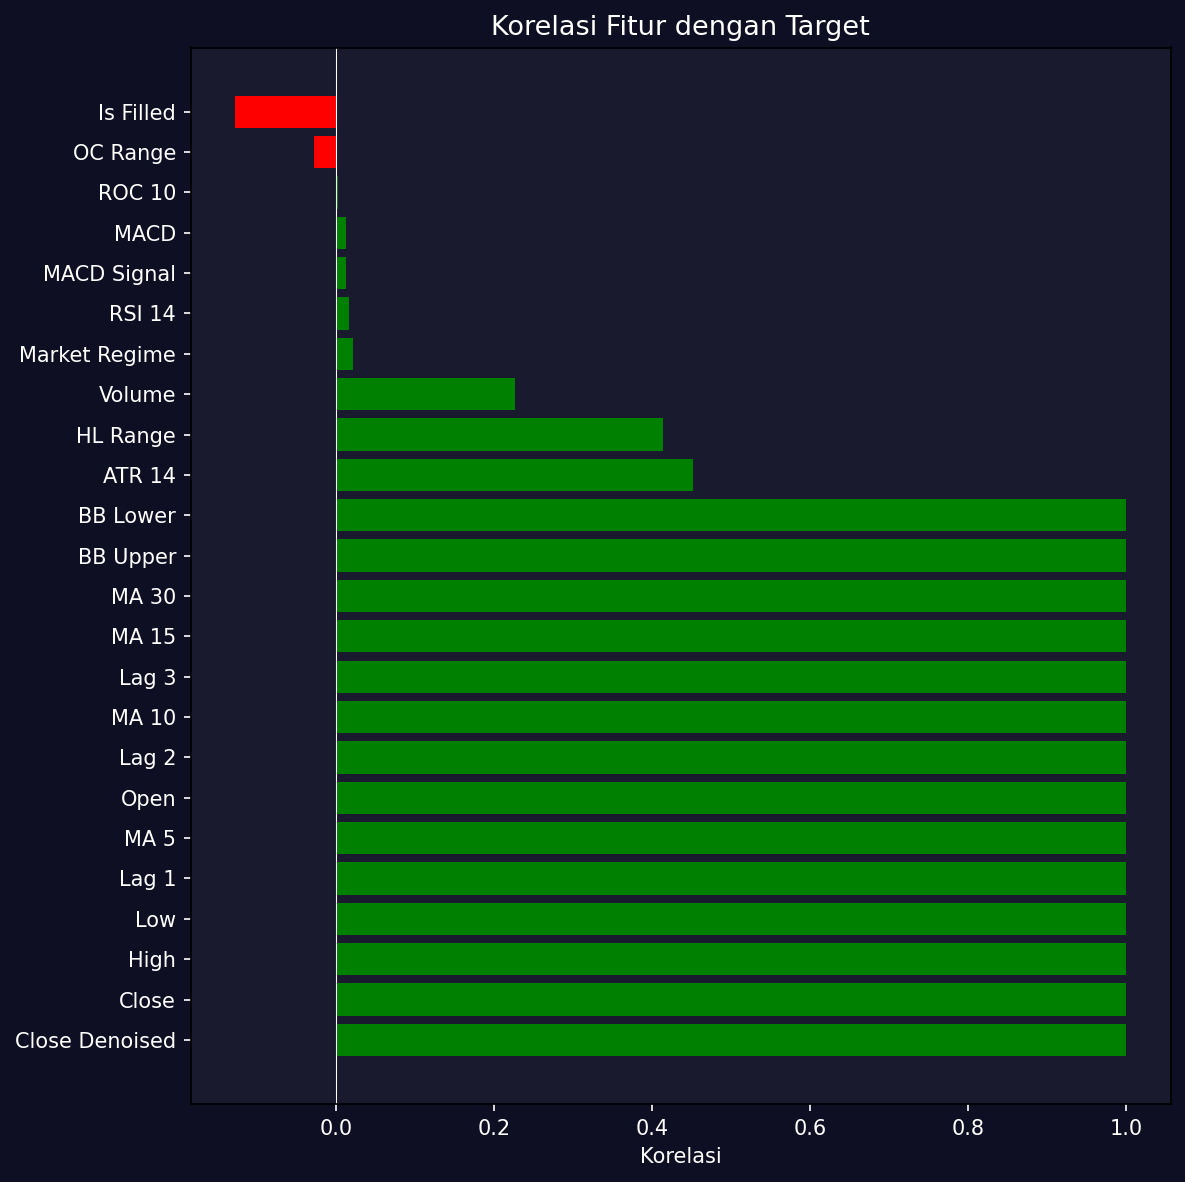

In [4]:
display(Image(VISUAL_PATH + 'feature_correlation.png'))

## 5. Alur Pipeline Data

### Pembagian Dataset
- **Total data**: 11,381,288 baris
- **Train (70%)**: 7,966,901 baris
- **Validasi (15%)**: 1,707,193 baris
- **Test (15%)**: 1,707,194 baris
- **Window Size**: 10 menit (input 10 menit → prediksi menit ke-11)

### Mengapa Split Sekuensial?
Data time series **tidak boleh di-shuffle** karena ada ketergantungan waktu. Train harus selalu sebelum Val, Val sebelum Test. Ini mencegah **data leakage** (bocornya informasi masa depan ke training).

/tmp/ipykernel_22536/3409100463.py:28: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


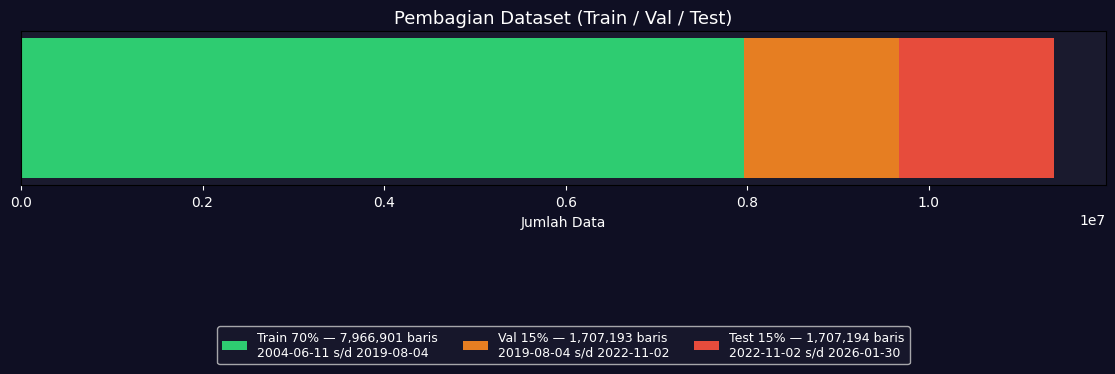

In [5]:
df_norm = pd.read_parquet(DATA_PATH + 'data_clean_normalized.parquet')

train_size = int(len(df_norm) * 0.7)
val_size = int(len(df_norm) * 0.15)

train_df = df_norm.iloc[:train_size]
val_df = df_norm.iloc[train_size:train_size+val_size]
test_df = df_norm.iloc[train_size+val_size:]

fig, ax = plt.subplots(figsize=(14, 2))

ax.barh(0, len(train_df), color='#2ecc71',
        label=f'Train 70% — {len(train_df):,} baris\n{train_df.index.min().date()} s/d {train_df.index.max().date()}')
ax.barh(0, len(val_df), left=len(train_df), color='#e67e22',
        label=f'Val 15% — {len(val_df):,} baris\n{val_df.index.min().date()} s/d {val_df.index.max().date()}')
ax.barh(0, len(test_df), left=len(train_df)+len(val_df), color='#e74c3c',
        label=f'Test 15% — {len(test_df):,} baris\n{test_df.index.min().date()} s/d {test_df.index.max().date()}')

ax.set_title('Pembagian Dataset (Train / Val / Test)', color='white', fontsize=13)
ax.legend(loc='lower center', bbox_to_anchor=(0.5, -1.2), ncol=3,
          facecolor='#1a1a2e', labelcolor='white', fontsize=9)
ax.set_yticks([])
ax.set_xlabel('Jumlah Data', color='white')
ax.set_facecolor('#1a1a2e')
ax.tick_params(colors='white')

fig.patch.set_facecolor('#0f0f23')
plt.tight_layout()
plt.show()

## 6. Model yang Digunakan (Aspek 1)

### 6.1 XGBoost (eXtreme Gradient Boosting)

**Cara Kerja:**
XGBoost membangun banyak decision tree secara bertahap (ensemble). Setiap tree baru mencoba memperbaiki error dari tree sebelumnya menggunakan gradient descent.

Input: 24 fitur (tabular, tanpa sliding window)

↓

Tree 1: prediksi awal

↓

Tree 2: perbaiki error Tree 1

↓

... (500 tree)

↓

Output: prediksi harga t+1

**Parameter:**
- n_estimators = 500 (jumlah tree)
- max_depth = 6 (kedalaman tree)
- learning_rate = 0.05
- device = cuda (GPU RTX 3050)

---

### 6.2 N-HiTS (Neural Hierarchical Interpolation for Time Series)

**Cara Kerja:**
N-HiTS menggunakan multi-rate signal sampling dengan 3 stack hierarki. Setiap stack menangkap pola di skala waktu berbeda (pendek, menengah, panjang), lalu hasilnya digabungkan.

Input: 10 menit historis (window_size=10) + 24 fitur covariates

↓

Stack 1: pola jangka pendek (1-3 menit)

Stack 2: pola menengah (3-7 menit)

Stack 3: pola panjang (7-10 menit)

↓

Interpolation & Combination

↓

Output: prediksi harga t+1

**Parameter:**
- input_chunk_length = 10
- num_stacks = 3
- layer_widths = 512
- n_epochs = 5
- batch_size = 256

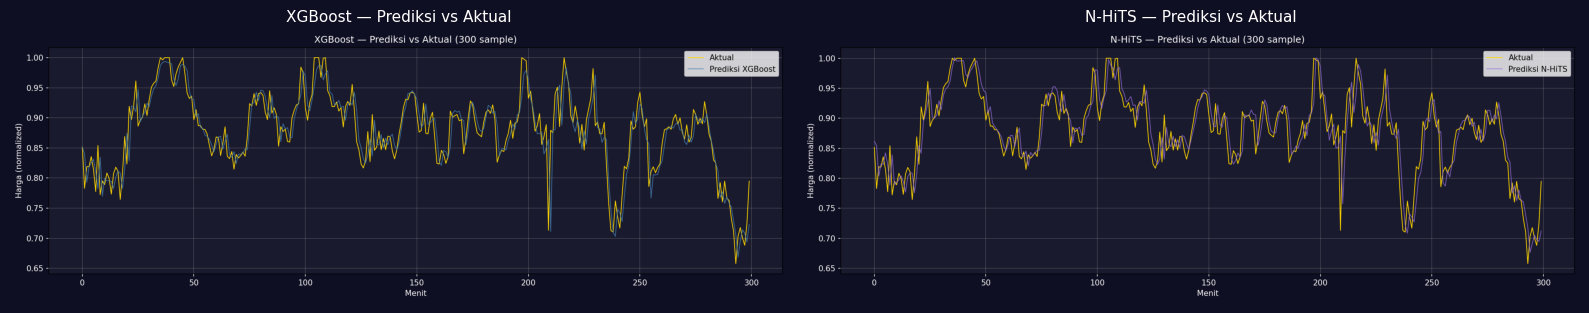

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

img_xgb = plt.imread(VISUAL_PATH + 'xgb_prediction.png')
axes[0].imshow(img_xgb)
axes[0].axis('off')
axes[0].set_title('XGBoost — Prediksi vs Aktual', color='white', fontsize=11)

img_nhits = plt.imread(VISUAL_PATH + 'nhits_prediction.png')
axes[1].imshow(img_nhits)
axes[1].axis('off')
axes[1].set_title('N-HiTS — Prediksi vs Aktual', color='white', fontsize=11)

fig.patch.set_facecolor('#0f0f23')
plt.tight_layout()
plt.show()

## 7. Checklist CI — Continuous Integration (Aspek 2)

CI adalah proses **pengecekan kualitas data sebelum training** dilakukan. Terdiri dari 3 kategori:

- **Unit Test**: Cek integritas dasar data (kolom, nilai)
- **Data Validation**: Cek kualitas & konsistensi data
- **Training Verification**: Cek kesiapan data untuk training

In [8]:
ci_data = [
    ('Unit Test', 'Kolom OHLCV lengkap', '✅', '5 kolom dasar tersedia'),
    ('Unit Test', 'Tidak ada harga ≤ 0', '✅', 'Sudah divalidasi'),
    ('Unit Test', 'High ≥ Low', '✅', 'Sudah divalidasi'),
    ('Data Validation', 'Tidak ada missing value', '✅', 'Sudah di-fill dengan forward fill'),
    ('Data Validation', 'Tidak ada duplikat timestamp', '✅', 'Sudah dihapus'),
    ('Data Validation', 'Frekuensi data konsisten (1 menit)', '✅', "asfreq('1min') diterapkan"),
    ('Training Verification', 'Data sudah dinormalisasi', '✅', 'Adaptive normalization (window 1000)'),
    ('Training Verification', 'Split train/val/test tidak bocor', '✅', 'Split sekuensial 70/15/15'),
    ('Training Verification', 'Shape data sesuai input model', '✅', 'XGBoost: (n,24) | N-HiTS: (n,10,24)'),
]

ci_df = pd.DataFrame(ci_data,
    columns=['Kategori', 'Item Checklist', 'Status', 'Keterangan'])
ci_df.index = range(1, len(ci_df)+1)

print("📋 TABEL CHECKLIST CI")
display(ci_df)

📋 TABEL CHECKLIST CI


,Kategori,Item Checklist,Status,Keterangan
1,Unit Test,Kolom OHLCV lengkap,✅,5 kolom dasar tersedia
2,Unit Test,Tidak ada harga ≤ 0,✅,Sudah divalidasi
3,Unit Test,High ≥ Low,✅,Sudah divalidasi
4,Data Validation,Tidak ada missing value,✅,Sudah di-fill dengan forward fill
5,Data Validation,Tidak ada duplikat timestamp,✅,Sudah dihapus
6,Data Validation,Frekuensi data konsisten (1 menit),✅,asfreq('1min') diterapkan
7,Training Verification,Data sudah dinormalisasi,✅,Adaptive normalization (window 1000)
8,Training Verification,Split train/val/test tidak bocor,✅,Split sekuensial 70/15/15
9,Training Verification,Shape data sesuai input model,✅,"XGBoost: (n,24) | N-HiTS: (n,10,24)"


## 8. Checklist CT — Continuous Training (Aspek 3)

CT adalah proses **pengecekan kualitas model setelah training** selesai.

### Penjelasan Metrik Evaluasi

| Metrik | Kepanjangan | Penjelasan | Target |
|---|---|---|---|
| **MAE** | Mean Absolute Error | Rata-rata selisih absolut prediksi vs aktual (dalam skala normalized) | < 0.02 |
| **RMSE** | Root Mean Squared Error | Akar rata-rata kuadrat error (lebih sensitif ke outlier) | < 0.03 |
| **MAPE** | Mean Absolute Percentage Error | Error dalam persentase dari nilai aktual | < 10% |
| **DA** | Directional Accuracy | % prediksi arah (naik/turun) yang benar | > 50% |

### Konversi ke Nilai Dolar
Karena data dinormalisasi, estimasi error dalam dolar:
- Range harga lokal (1000 menit) ≈ $50–150
- MAE 0.011 × $100 ≈ **$1.1 per prediksi**
- MAE 0.013 × $100 ≈ **$1.3 per prediksi**

Untuk trading harga emas ~$3,300, error $1-2 per menit sangat acceptable.

📊 TABEL PERBANDINGAN MODEL


,Model,MAE,RMSE,MAPE (%),Directional Accuracy (%),Est. Error ($)
0,XGBoost,0.011483,0.023757,5.660210,34.878189,1.150000
1,N-HiTS,0.012949,0.026387,6.095941,55.273012,1.290000


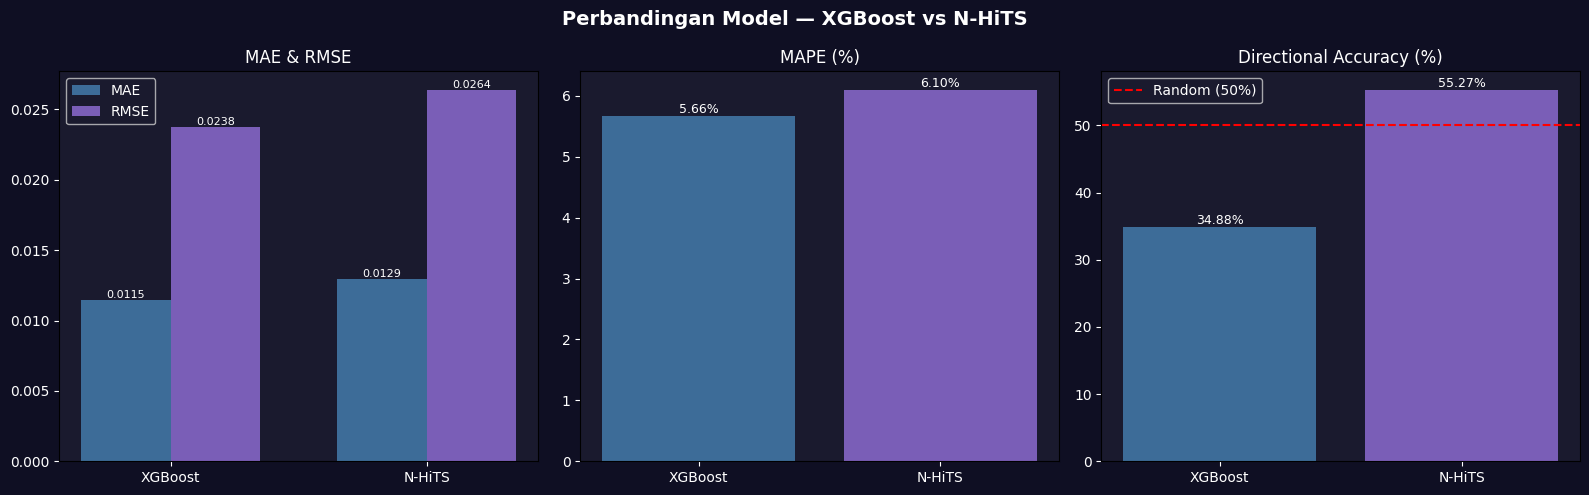

✅ Visualisasi perbandingan berhasil!


In [9]:
with open(MODEL_PATH + 'results_xgb.json') as f:
    res_xgb = json.load(f)
with open(MODEL_PATH + 'results_nhits.json') as f:
    res_nhits = json.load(f)

results_df = pd.DataFrame([res_xgb, res_nhits])
results_df = results_df.round(6)
results_df['Est. Error ($)'] = (results_df['MAE'] * 100).round(2)

print("📊 TABEL PERBANDINGAN MODEL")
display(results_df.style
    .highlight_min(subset=['MAE', 'RMSE', 'MAPE (%)'], color='lightgreen')
    .highlight_max(subset=['Directional Accuracy (%)'], color='lightgreen')
    .set_properties(**{'text-align': 'center'})
)

# Bar chart
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Perbandingan Model — XGBoost vs N-HiTS',
             color='white', fontsize=14, fontweight='bold')

models = results_df['Model'].tolist()
colors = ['steelblue', 'mediumpurple']
x = np.arange(len(models))
width = 0.35

# MAE & RMSE
bars1 = axes[0].bar(x-width/2, results_df['MAE'], width, label='MAE', color='steelblue', alpha=0.8)
bars2 = axes[0].bar(x+width/2, results_df['RMSE'], width, label='RMSE', color='mediumpurple', alpha=0.8)
axes[0].set_title('MAE & RMSE', color='white')
axes[0].set_xticks(x)
axes[0].set_xticklabels(models, color='white')
axes[0].legend(facecolor='#1a1a2e', labelcolor='white')
axes[0].set_facecolor('#1a1a2e')
axes[0].tick_params(colors='white')
axes[0].bar_label(bars1, fmt='%.4f', color='white', fontsize=8)
axes[0].bar_label(bars2, fmt='%.4f', color='white', fontsize=8)

# MAPE
bars3 = axes[1].bar(models, results_df['MAPE (%)'], color=colors, alpha=0.8)
axes[1].set_title('MAPE (%)', color='white')
axes[1].set_facecolor('#1a1a2e')
axes[1].tick_params(colors='white')
axes[1].bar_label(bars3, fmt='%.2f%%', color='white', fontsize=9)
for tick in axes[1].get_xticklabels():
    tick.set_color('white')

# DA
bars4 = axes[2].bar(models, results_df['Directional Accuracy (%)'], color=colors, alpha=0.8)
axes[2].axhline(y=50, color='red', linestyle='--', linewidth=1.5, label='Random (50%)')
axes[2].set_title('Directional Accuracy (%)', color='white')
axes[2].set_facecolor('#1a1a2e')
axes[2].tick_params(colors='white')
axes[2].legend(facecolor='#1a1a2e', labelcolor='white')
axes[2].bar_label(bars4, fmt='%.2f%%', color='white', fontsize=9)
for tick in axes[2].get_xticklabels():
    tick.set_color('white')

fig.patch.set_facecolor('#0f0f23')
plt.tight_layout()
plt.savefig(VISUAL_PATH + 'model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Visualisasi perbandingan berhasil!")

In [11]:
best_mae_val = results_df['MAE'].min()
best_rmse_val = results_df['RMSE'].min()
best_da_val = results_df['Directional Accuracy (%)'].max()

ct_data = [
    ('Metrik Performa', 'MAE < 0.02',
     '✅' if best_mae_val < 0.02 else '❌',
     f'Terbaik: {best_mae_val:.6f}'),
    ('Metrik Performa', 'RMSE < 0.03',
     '✅' if best_rmse_val < 0.03 else '❌',
     f'Terbaik: {best_rmse_val:.6f}'),
    ('Metrik Performa', 'Directional Accuracy > 50%',
     '✅' if best_da_val > 50 else '❌',
     f'Terbaik: {best_da_val:.2f}%'),
    ('Fairness', 'Performa konsisten di semua Market Regime',
     '⚠️', 'Perlu analisis per regime (future work)'),
    ('Robustness', 'Model stabil saat volatilitas tinggi (ATR tinggi)',
     '⚠️', 'Perlu evaluasi saat news event (future work)'),
]

ct_df = pd.DataFrame(ct_data,
    columns=['Kategori', 'Item Checklist', 'Status', 'Keterangan'])
ct_df.index = range(1, len(ct_df)+1)

print("📋 TABEL CHECKLIST CT")
display(ct_df)

📋 TABEL CHECKLIST CT


,Kategori,Item Checklist,Status,Keterangan
1,Metrik Performa,MAE < 0.02,✅,Terbaik: 0.011483
2,Metrik Performa,RMSE < 0.03,✅,Terbaik: 0.023757
3,Metrik Performa,Directional Accuracy > 50%,✅,Terbaik: 55.27%
4,Fairness,Performa konsisten di semua Market Regime,⚠️,Perlu analisis per regime (future work)
5,Robustness,Model stabil saat volatilitas tinggi (ATR tinggi),⚠️,Perlu evaluasi saat news event (future work)


## 9. Skenario CD — Continuous Deployment (Aspek 4)

CD adalah proses **pengiriman model ke production** agar bisa digunakan secara real-time.

### Komponen CD
- **Format Model**: Model disimpan dalam format yang bisa dipakai langsung
- **API**: Antarmuka untuk aplikasi lain mengakses prediksi
- **Registry**: Tempat penyimpanan & versioning model
- **Strategi**: Kapan model lama diganti model baru
- **CI/CD Tool**: Otomasi seluruh pipeline

In [12]:
cd_data = [
    ('1', 'Format Model', 'XGBoost: .json + .pkl | N-HiTS: .pt (PyTorch)'),
    ('2', 'API', 'FastAPI — endpoint POST /predict\nInput: 10 menit data OHLCV terakhir\nOutput: harga prediksi t+1 (float)'),
    ('3', 'Model Registry', 'MLflow Model Registry\nVersioning otomatis setiap retrain\nTracking: MAE, RMSE, MAPE, DA'),
    ('4', 'Strategi Deployment', 'Retrain otomatis jika:\n- RMSE naik >10% dari baseline\n- Atau setiap 7 hari sekali\nBlue-green deployment (zero downtime)'),
    ('5', 'Data Realtime', 'MetaTrader 5 API / Twelve Data API\nData baru masuk setiap 1 menit\nPrediksi dikirim ke dashboard trading'),
    ('6', 'CI/CD Tool', 'GitHub Actions\n- Push kode → trigger unit test (CI)\n- Model baru lebih baik → deploy otomatis (CD)'),
    ('7', 'Monitoring', 'MLflow + alert sistem\nAlert jika DA < 52% selama 1 jam\nLog semua prediksi vs aktual harian'),
]

cd_df = pd.DataFrame(cd_data, columns=['No', 'Aspek', 'Detail'])
cd_df = cd_df.set_index('No')

print("📋 TABEL SKENARIO CD")
display(cd_df)

📋 TABEL SKENARIO CD


,Aspek,Detail
No,,
1,Format Model,XGBoost: .json + .pkl | N-HiTS: .pt (PyTorch)
2,API,FastAPI — endpoint POST /predict\nInput: 10 me...
3,Model Registry,MLflow Model Registry\nVersioning otomatis set...
4,Strategi Deployment,Retrain otomatis jika:\n- RMSE naik >10% dari ...
5,Data Realtime,MetaTrader 5 API / Twelve Data API\nData baru ...
6,CI/CD Tool,GitHub Actions\n- Push kode → trigger unit tes...
7,Monitoring,MLflow + alert sistem\nAlert jika DA < 52% sel...


## 10. Diagram Pipeline MLOps

/tmp/ipykernel_22536/3241643221.py:45: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans.
  plt.savefig(VISUAL_PATH + 'pipeline_mlops.png', dpi=150,
/tmp/ipykernel_22536/3241643221.py:45: UserWarning: Glyph 128230 (\N{PACKAGE}) missing from font(s) DejaVu Sans.
  plt.savefig(VISUAL_PATH + 'pipeline_mlops.png', dpi=150,
/tmp/ipykernel_22536/3241643221.py:45: UserWarning: Glyph 128295 (\N{WRENCH}) missing from font(s) DejaVu Sans.
  plt.savefig(VISUAL_PATH + 'pipeline_mlops.png', dpi=150,
/tmp/ipykernel_22536/3241643221.py:45: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  plt.savefig(VISUAL_PATH + 'pipeline_mlops.png', dpi=150,
/tmp/ipykernel_22536/3241643221.py:45: UserWarning: Glyph 127794 (\N{EVERGREEN TREE}) missing from font(s) DejaVu Sans.
  plt.savefig(VISUAL_PATH + 'pipeline_mlops.png', dpi=150,
/tmp/ipykernel_22536/3241643221.py:45: UserWarning: Glyph 129504 (\N{BRAIN}) missing from font(s) DejaVu Sans.
 

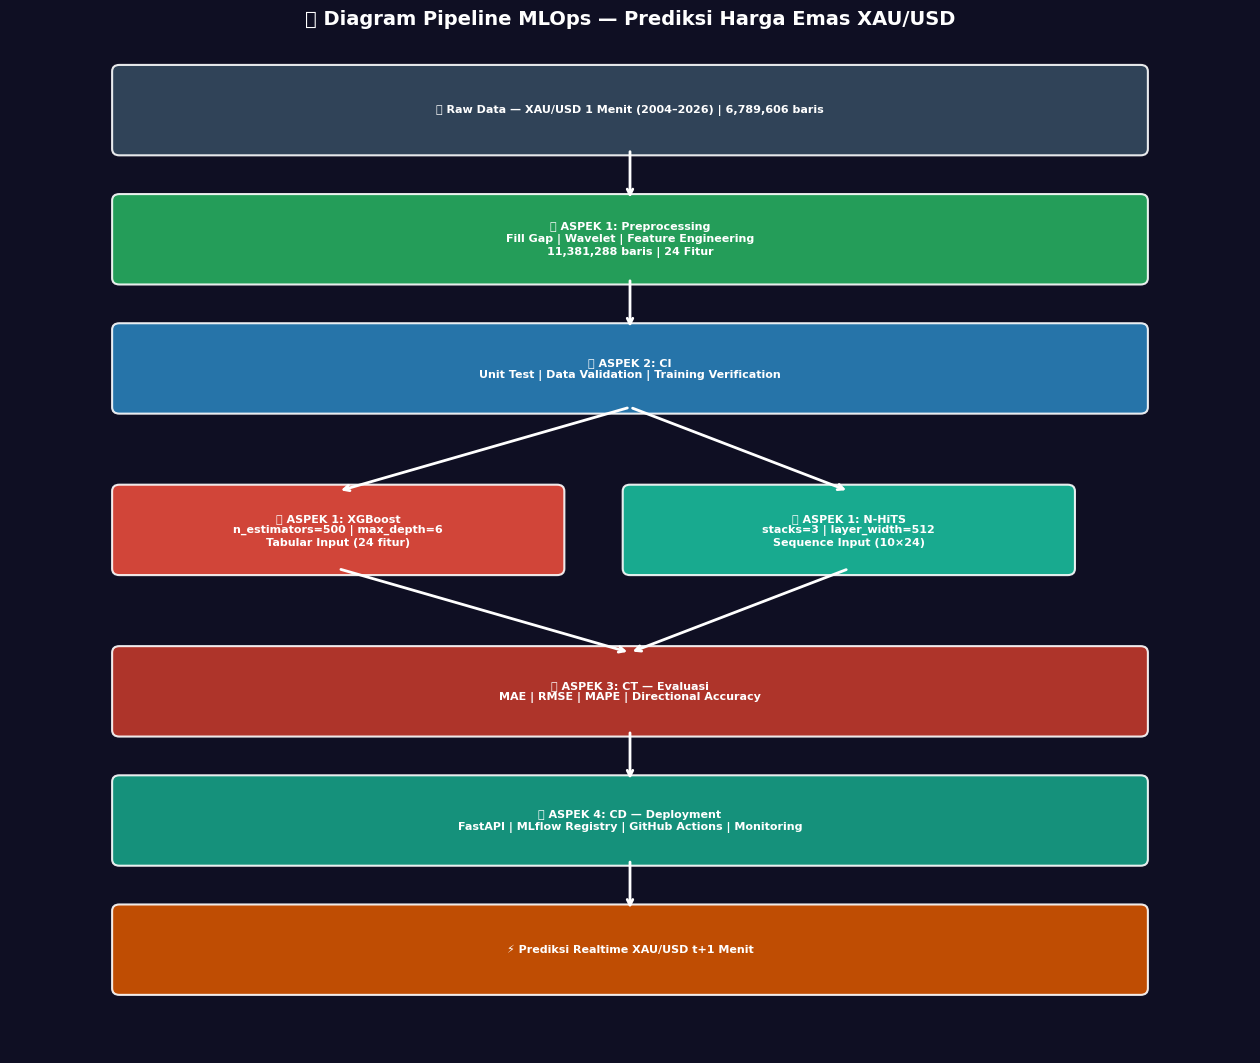

✅ Diagram Pipeline MLOps berhasil!


In [16]:
fig, ax = plt.subplots(figsize=(16, 13))
ax.set_xlim(-0.5, 16.5)
ax.set_ylim(-0.5, 15)
ax.axis('off')
fig.patch.set_facecolor('#0f0f23')

stages = [
    (8, 13.5, 14, 1.2, '📦 Raw Data — XAU/USD 1 Menit (2004–2026) | 6,789,606 baris', '#34495e'),
    (8, 11.5, 14, 1.2, '🔧 ASPEK 1: Preprocessing\nFill Gap | Wavelet | Feature Engineering\n11,381,288 baris | 24 Fitur', '#27ae60'),
    (8, 9.5, 14, 1.2, '🔍 ASPEK 2: CI\nUnit Test | Data Validation | Training Verification', '#2980b9'),
    (4, 7, 6, 1.2, '🌲 ASPEK 1: XGBoost\nn_estimators=500 | max_depth=6\nTabular Input (24 fitur)', '#e74c3c'),
    (11, 7, 6, 1.2, '🧠 ASPEK 1: N-HiTS\nstacks=3 | layer_width=512\nSequence Input (10×24)', '#1abc9c'),
    (8, 4.5, 14, 1.2, '✅ ASPEK 3: CT — Evaluasi\nMAE | RMSE | MAPE | Directional Accuracy', '#c0392b'),
    (8, 2.5, 14, 1.2, '🚀 ASPEK 4: CD — Deployment\nFastAPI | MLflow Registry | GitHub Actions | Monitoring', '#16a085'),
    (8, 0.5, 14, 1.2, '⚡ Prediksi Realtime XAU/USD t+1 Menit', '#d35400'),
]

for x, y, w, h, text, color in stages:
    box = FancyBboxPatch((x-w/2, y), w, h,
                          boxstyle="round,pad=0.1",
                          facecolor=color, edgecolor='white',
                          linewidth=1.5, alpha=0.9)
    ax.add_patch(box)
    ax.text(x, y+h/2, text, ha='center', va='center',
            color='white', fontsize=8, fontweight='bold')

arrow_props = dict(arrowstyle='->', color='white', lw=2)
arrows = [
    (8, 13.5, 8, 12.7),    # Raw Data -> Preprocessing
    (8, 11.5, 8, 10.7),    # Preprocessing -> CI
    (8, 9.5, 4, 8.2),      # CI -> XGBoost
    (8, 9.5, 11, 8.2),     # CI -> N-HiTS
    (4, 7, 8, 5.7),        # XGBoost -> Evaluasi
    (11, 7, 8, 5.7),       # N-HiTS -> Evaluasi
    (8, 4.5, 8, 3.7),      # Evaluasi -> Deployment
    (8, 2.5, 8, 1.7),      # Deployment -> Prediksi Realtime
]

for x1, y1, x2, y2 in arrows:
    ax.annotate('', xy=(x2, y2), xytext=(x1, y1), arrowprops=arrow_props)

ax.set_title('🏆 Diagram Pipeline MLOps — Prediksi Harga Emas XAU/USD',
             color='white', fontsize=14, fontweight='bold', pad=20)

plt.savefig(VISUAL_PATH + 'pipeline_mlops.png', dpi=150,
            facecolor='#0f0f23', bbox_inches='tight', pad_inches=0.3)
plt.show()
print("✅ Diagram Pipeline MLOps berhasil!")

## 11. Kesimpulan

### Model Terbaik: N-HiTS

Berdasarkan evaluasi komprehensif menggunakan 4 metrik, **N-HiTS dipilih sebagai model terbaik** untuk deployment prediksi harga emas real-time.

### Alasan Pemilihan N-HiTS
1. **Directional Accuracy 55.27%** — di atas random (50%), artinya model bisa memprediksi arah naik/turun lebih sering benar daripada salah
2. Untuk **trading real-time**, arah pergerakan lebih penting dari nilai absolut harga
3. N-HiTS dirancang khusus untuk time series, lebih sesuai dengan karakteristik data harga emas

### Perbandingan Akhir

| Kriteria | XGBoost | N-HiTS | Pemenang |
|---|---|---|---|
| MAE | **0.011483** | 0.012949 | XGBoost |
| RMSE | **0.023757** | 0.026387 | XGBoost |
| MAPE | **5.66%** | 6.10% | XGBoost |
| Directional Accuracy | 34.88% | **55.27%** | N-HiTS |
| Estimasi Error | **~1.15 USD** | ~1.29 USD | XGBoost |
| **Rekomendasi Penggunaan** | Analisis & Reporting | **Deployment Trading** | **N-HiTS** |

> 💡 **Insight:** Meskipun XGBoost unggul di metrik error absolut (MAE, RMSE, MAPE), N-HiTS jauh lebih superior dalam **Directional Accuracy** (55.27% vs 34.88%). Untuk konteks trading, kemampuan memprediksi **arah** pergerakan harga lebih krusial dibanding kecilnya error nilai — sehingga **N-HiTS direkomendasikan untuk deployment trading**, sementara XGBoost lebih cocok untuk kebutuhan analisis/reporting harga.

> 💡 **Insight:** Meskipun XGBoost unggul di metrik error absolut (MAE, RMSE, MAPE), N-HiTS jauh lebih superior dalam **Directional Accuracy** (55.27% vs 34.88%). Untuk konteks trading, kemampuan memprediksi **arah** pergerakan harga lebih krusial dibanding kecilnya error nilai — sehingga **N-HiTS direkomendasikan untuk deployment trading**, sementara XGBoost lebih cocok untuk kebutuhan analisis/reporting harga.

### Rekomendasi Pengembangan
1. **Implementasi TFT** sebagai model ketiga (Temporal Fusion Transformer) untuk perbandingan lebih lengkap
2. **Ensemble XGBoost + N-HiTS** — kombinasikan akurasi harga XGBoost dengan kemampuan arah N-HiTS
3. **Deploy FastAPI** dengan endpoint prediksi setiap menit via MetaTrader 5 API
4. **Monitoring MLflow** — alert otomatis jika DA turun di bawah 52%
5. **Retrain otomatis** setiap 7 hari atau jika RMSE naik >10%